In [7]:
# Importar librerías
import os
import numpy as np
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
import shutil

# Rutas
DATA_PATH = Path("../data/archive")
OUTPUT_PATH = Path("../data/procesado")

# Configuración
IMG_SIZE = (224, 224)  # Tamaño para el modelo
SEED = 42  # Para reproducibilidad

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [2]:
# ============================================================
# 1. CREAR ESTRUCTURA DE CARPETAS
# ============================================================

# Crear carpetas para datos procesados
carpetas = [
    OUTPUT_PATH / "train" / "normal",
    OUTPUT_PATH / "train" / "anormal",
    OUTPUT_PATH / "validation" / "normal",
    OUTPUT_PATH / "validation" / "anormal",
    OUTPUT_PATH / "test" / "normal",
    OUTPUT_PATH / "test" / "anormal",
]

for carpeta in carpetas:
    carpeta.mkdir(parents=True, exist_ok=True)

print("✅ Estructura de carpetas creada:")
print("""
📁 data/procesado/
├── 📁 train/
│   ├── 📁 normal/
│   └── 📁 anormal/
├── 📁 validation/
│   ├── 📁 normal/
│   └── 📁 anormal/
└── 📁 test/
    ├── 📁 normal/
    └── 📁 anormal/
""")

✅ Estructura de carpetas creada:

📁 data/procesado/
├── 📁 train/
│   ├── 📁 normal/
│   └── 📁 anormal/
├── 📁 validation/
│   ├── 📁 normal/
│   └── 📁 anormal/
└── 📁 test/
    ├── 📁 normal/
    └── 📁 anormal/



In [3]:
# ============================================================
# 2. CLASIFICAR IMÁGENES (NORMAL vs ANORMAL)
# ============================================================

# Definir qué clases son normales y anormales
clases_anormales = ['im_Dyskeratotic', 'im_Koilocytotic']
clases_normales = ['im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']

# Recolectar todas las imágenes
imagenes_normales = []
imagenes_anormales = []

for clase in clases_normales:
    clase_path = DATA_PATH / clase / clase
    imagenes = list(clase_path.glob("*.bmp"))
    imagenes_normales.extend(imagenes)

for clase in clases_anormales:
    clase_path = DATA_PATH / clase / clase
    imagenes = list(clase_path.glob("*.bmp"))
    imagenes_anormales.extend(imagenes)

print(f"📊 Imágenes recolectadas:")
print(f"   • Normales:  {len(imagenes_normales)}")
print(f"   • Anormales: {len(imagenes_anormales)}")
print(f"   • Total:     {len(imagenes_normales) + len(imagenes_anormales)}")

📊 Imágenes recolectadas:
   • Normales:  505
   • Anormales: 461
   • Total:     966


In [4]:
# ============================================================
# 2.1 CORREGIR: Buscar también archivos .BMP (mayúsculas)
# ============================================================

# Recolectar todas las imágenes (bmp y BMP)
imagenes_normales = []
imagenes_anormales = []

for clase in clases_normales:
    clase_path = DATA_PATH / clase / clase
    imagenes = list(clase_path.glob("*.bmp")) + list(clase_path.glob("*.BMP"))
    imagenes_normales.extend(imagenes)

for clase in clases_anormales:
    clase_path = DATA_PATH / clase / clase
    imagenes = list(clase_path.glob("*.bmp")) + list(clase_path.glob("*.BMP"))
    imagenes_anormales.extend(imagenes)

print(f"📊 Imágenes recolectadas (corregido):")
print(f"   • Normales:  {len(imagenes_normales)}")
print(f"   • Anormales: {len(imagenes_anormales)}")
print(f"   • Total:     {len(imagenes_normales) + len(imagenes_anormales)}")

📊 Imágenes recolectadas (corregido):
   • Normales:  1010
   • Anormales: 922
   • Total:     1932


In [5]:
# ============================================================
# 3. DIVIDIR EN TRAIN / VALIDATION / TEST (70/15/15)
# ============================================================

# Dividir normales
train_norm, temp_norm = train_test_split(imagenes_normales, test_size=0.30, random_state=SEED)
val_norm, test_norm = train_test_split(temp_norm, test_size=0.50, random_state=SEED)

# Dividir anormales
train_anorm, temp_anorm = train_test_split(imagenes_anormales, test_size=0.30, random_state=SEED)
val_anorm, test_anorm = train_test_split(temp_anorm, test_size=0.50, random_state=SEED)

print("📊 División de datos:")
print(f"""
┌─────────────┬──────────┬──────────┬──────────┐
│   Conjunto  │  Normal  │ Anormal  │  Total   │
├─────────────┼──────────┼──────────┼──────────┤
│ Train (70%) │   {len(train_norm):4}   │   {len(train_anorm):4}   │   {len(train_norm)+len(train_anorm):4}   │
│ Valid (15%) │   {len(val_norm):4}   │   {len(val_anorm):4}   │   {len(val_norm)+len(val_anorm):4}   │
│ Test  (15%) │   {len(test_norm):4}   │   {len(test_anorm):4}   │   {len(test_norm)+len(test_anorm):4}   │
├─────────────┼──────────┼──────────┼──────────┤
│    Total    │   {len(imagenes_normales):4}   │   {len(imagenes_anormales):4}   │   {len(imagenes_normales)+len(imagenes_anormales):4}   │
└─────────────┴──────────┴──────────┴──────────┘
""")

📊 División de datos:

┌─────────────┬──────────┬──────────┬──────────┐
│   Conjunto  │  Normal  │ Anormal  │  Total   │
├─────────────┼──────────┼──────────┼──────────┤
│ Train (70%) │    707   │    645   │   1352   │
│ Valid (15%) │    151   │    138   │    289   │
│ Test  (15%) │    152   │    139   │    291   │
├─────────────┼──────────┼──────────┼──────────┤
│    Total    │   1010   │    922   │   1932   │
└─────────────┴──────────┴──────────┴──────────┘



In [6]:
# ============================================================
# 4. PROCESAR Y GUARDAR IMÁGENES
# ============================================================

def procesar_y_guardar(lista_imagenes, carpeta_destino, clase):
    """Redimensiona y guarda las imágenes"""
    for i, img_path in enumerate(lista_imagenes):
        # Cargar imagen
        img = Image.open(img_path)
        
        # Redimensionar a 224x224
        img_resized = img.resize(IMG_SIZE, Image.LANCZOS)
        
        # Convertir a RGB si es necesario
        if img_resized.mode != 'RGB':
            img_resized = img_resized.convert('RGB')
        
        # Guardar
        nombre = f"{clase}_{i:04d}.jpg"
        img_resized.save(carpeta_destino / nombre, 'JPEG', quality=95)
    
    return len(lista_imagenes)

print("⏳ Procesando imágenes...")
print("   (Esto puede tomar unos minutos)\n")

# Procesar TRAIN
n1 = procesar_y_guardar(train_norm, OUTPUT_PATH / "train" / "normal", "normal")
n2 = procesar_y_guardar(train_anorm, OUTPUT_PATH / "train" / "anormal", "anormal")
print(f"✅ Train:      {n1 + n2} imágenes procesadas")

# Procesar VALIDATION
n3 = procesar_y_guardar(val_norm, OUTPUT_PATH / "validation" / "normal", "normal")
n4 = procesar_y_guardar(val_anorm, OUTPUT_PATH / "validation" / "anormal", "anormal")
print(f"✅ Validation: {n3 + n4} imágenes procesadas")

# Procesar TEST
n5 = procesar_y_guardar(test_norm, OUTPUT_PATH / "test" / "normal", "normal")
n6 = procesar_y_guardar(test_anorm, OUTPUT_PATH / "test" / "anormal", "anormal")
print(f"✅ Test:       {n5 + n6} imágenes procesadas")

print(f"\n🎉 ¡COMPLETADO! {n1+n2+n3+n4+n5+n6} imágenes procesadas en total")

⏳ Procesando imágenes...
   (Esto puede tomar unos minutos)

✅ Train:      1352 imágenes procesadas
✅ Validation: 289 imágenes procesadas
✅ Test:       291 imágenes procesadas

🎉 ¡COMPLETADO! 1932 imágenes procesadas en total


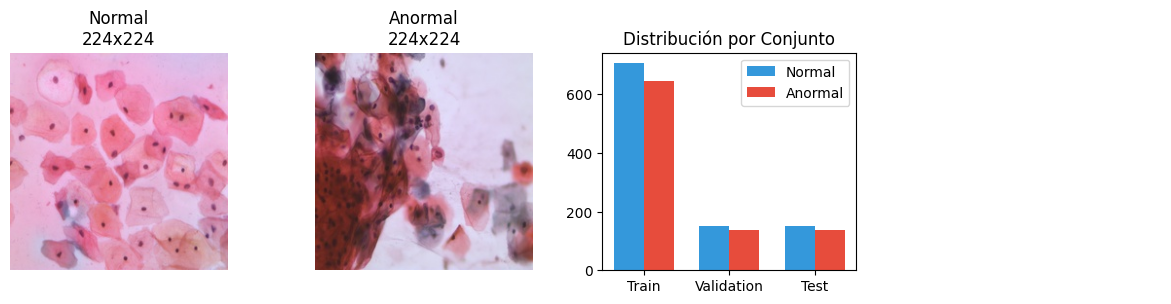

✅ Gráfico guardado en: data/03_datos_procesados.png


In [9]:
# ============================================================
# 5. VERIFICAR DATOS PROCESADOS
# ============================================================

import matplotlib.pyplot as plt

# Contar archivos guardados
def contar_imagenes(path):
    return len(list(path.glob("*.jpg")))

train_n = contar_imagenes(OUTPUT_PATH / "train" / "normal")
train_a = contar_imagenes(OUTPUT_PATH / "train" / "anormal")
val_n = contar_imagenes(OUTPUT_PATH / "validation" / "normal")
val_a = contar_imagenes(OUTPUT_PATH / "validation" / "anormal")
test_n = contar_imagenes(OUTPUT_PATH / "test" / "normal")
test_a = contar_imagenes(OUTPUT_PATH / "test" / "anormal")

# Mostrar ejemplo de imagen procesada
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

img_normal = list((OUTPUT_PATH / "train" / "normal").glob("*.jpg"))[0]
img_anormal = list((OUTPUT_PATH / "train" / "anormal").glob("*.jpg"))[0]

axes[0].imshow(Image.open(img_normal))
axes[0].set_title(f"Normal\n{IMG_SIZE[0]}x{IMG_SIZE[1]}")
axes[0].axis('off')

axes[1].imshow(Image.open(img_anormal))
axes[1].set_title(f"Anormal\n{IMG_SIZE[0]}x{IMG_SIZE[1]}")
axes[1].axis('off')

# Gráfico de distribución
conjuntos = ['Train', 'Validation', 'Test']
normales = [train_n, val_n, test_n]
anormales = [train_a, val_a, test_a]

x = np.arange(len(conjuntos))
width = 0.35

axes[2].bar(x - width/2, normales, width, label='Normal', color='#3498db')
axes[2].bar(x + width/2, anormales, width, label='Anormal', color='#e74c3c')
axes[2].set_xticks(x)
axes[2].set_xticklabels(conjuntos)
axes[2].legend()
axes[2].set_title('Distribución por Conjunto')

axes[3].axis('off')

plt.tight_layout()
plt.savefig('../data/03_datos_procesados.png', dpi=150)
plt.show()

print("✅ Gráfico guardado en: data/03_datos_procesados.png")

In [10]:
# ============================================================
# 6. CONCLUSIONES DEL PREPROCESAMIENTO
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════╗
║              PREPROCESAMIENTO COMPLETADO                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  ✅ Imágenes redimensionadas: 2048x1536 → 224x224            ║
║                                                              ║
║  ✅ Formato: JPEG (calidad 95%)                              ║
║                                                              ║
║  ✅ Clasificación binaria: Normal vs Anormal                 ║
║                                                              ║
║  ✅ División de datos:                                       ║
║     • Train:      1352 imágenes (70%)                        ║
║     • Validation:  289 imágenes (15%)                        ║
║     • Test:        291 imágenes (15%)                        ║
║                                                              ║
║  📁 Datos guardados en: data/procesado/                      ║
║                                                              ║
║  📋 PRÓXIMO PASO:                                            ║
║     → Entrenar modelo CNN con Transfer Learning              ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║              PREPROCESAMIENTO COMPLETADO                     ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  ✅ Imágenes redimensionadas: 2048x1536 → 224x224            ║
║                                                              ║
║  ✅ Formato: JPEG (calidad 95%)                              ║
║                                                              ║
║  ✅ Clasificación binaria: Normal vs Anormal                 ║
║                                                              ║
║  ✅ División de datos:                                       ║
║     • Train:      1352 imágenes (70%)                        ║
║     • Validation:  289 imágenes (15%)                        ║
║     • Test:        291 imágenes (15%)                        ║
║                                                              ║
║  📁 Datos guardados en: dat